In [40]:
import pandas as pd
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [41]:
housing_df = pd.read_csv(filepath_or_buffer = '~/ML/Datasets/california-housing.csv')

1. Getting more info about the data:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block group is the smallest geographical unit for which the U.S.
Census Bureau publishes sample data (a block group typically has a population
of 600 to 3,000 people).

A household is a group of people residing within a home. Since the average
number of rooms and bedrooms in this dataset are provided per household, these
columns may take surprisingly large values for block groups with few households
and many empty houses, such as vacation resorts.

It can be downloaded/loaded using the
:func:`sklearn.datasets.fetch_california_housing` function.

.. rubric:: References

- Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions,
  Statistics and Probability Letters, 33 (1997) 291-297



2. Shape of the dataset: 
20640 rows and 10 columns (9 features and 1 response variable)

In [42]:
housing_df.shape

(20640, 10)

In [43]:
housing_df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [44]:
housing_df.head(n = 10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [45]:
#selecting 10 random rows from the data
#this avoids a bias where there is similarity of rows
housing_df.sample(n = 10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5339,-118.45,34.03,45.0,727.0,168.0,520.0,175.0,2.6528,300000.0,<1H OCEAN
4310,-118.32,34.09,30.0,1871.0,766.0,2595.0,819.0,2.0044,212500.0,<1H OCEAN
4166,-118.20,34.11,37.0,2040.0,611.0,1698.0,545.0,1.9355,166300.0,<1H OCEAN
6718,-118.16,34.13,36.0,4003.0,647.0,1337.0,631.0,7.7230,500001.0,<1H OCEAN
17182,-122.51,37.53,17.0,1574.0,262.0,672.0,241.0,7.2929,355800.0,NEAR OCEAN
11834,-120.22,39.20,22.0,8259.0,1409.0,845.0,353.0,3.3699,244000.0,INLAND
14566,-117.21,32.84,34.0,2158.0,366.0,1046.0,335.0,4.5402,182100.0,NEAR OCEAN
5463,-118.47,33.99,33.0,854.0,235.0,645.0,198.0,2.1471,239300.0,<1H OCEAN
3503,-118.44,34.27,29.0,1701.0,419.0,1616.0,371.0,3.3603,142400.0,<1H OCEAN
1783,-122.36,37.94,26.0,1540.0,343.0,1007.0,338.0,1.3365,72900.0,NEAR BAY


In [46]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [47]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [48]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [49]:
housing_df.duplicated().sum()

np.int64(0)

In [50]:
housing_df.corr(numeric_only = True)['median_house_value']

longitude            -0.045967
latitude             -0.144160
housing_median_age    0.105623
total_rooms           0.134153
total_bedrooms        0.049686
population           -0.024650
households            0.065843
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64

### Univariate Analysis
* 'Uni' means One and 'variate' a thing that can vary.
* So when we do an analysis of a single variable, its univariate analysis.
* We try to determine that which feature is a "good predictor" of the response variable.

#### Count plot for categorical values

<Axes: xlabel='ocean_proximity', ylabel='count'>

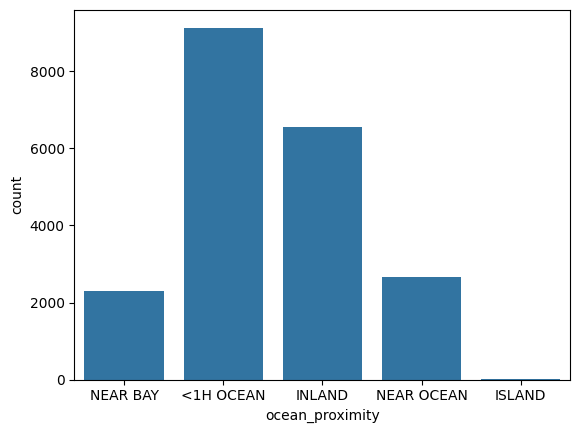

In [51]:
sns.countplot(data = housing_df, x = 'ocean_proximity')

In [52]:
px.histogram(data_frame = housing_df, x = 'ocean_proximity')

#### Piechart:

<Axes: >

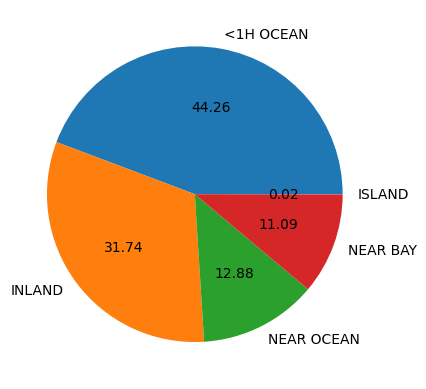

In [53]:
housing_df['ocean_proximity'].value_counts().plot(kind = 'pie', autopct = '%.2f')

In [54]:
px.pie(data_frame = housing_df, names = 'ocean_proximity')

### Numerical Data:

#### 1. Histogram

<Axes: xlabel='median_house_value', ylabel='Count'>

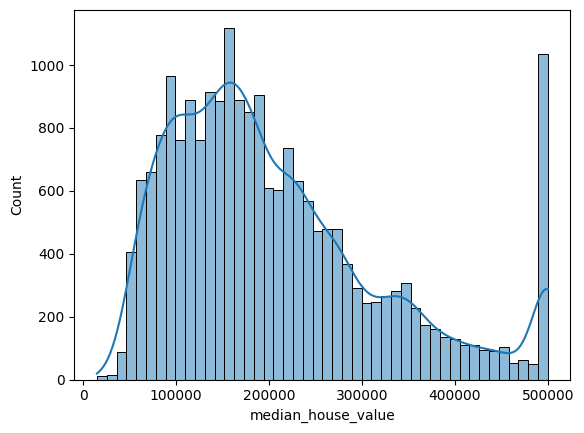

In [55]:
sns.histplot(data = housing_df, x = 'median_house_value', kde = True)

In [56]:
px.histogram(data_frame = housing_df, x = 'median_house_value')

#### 2. Distplot or KDE plot

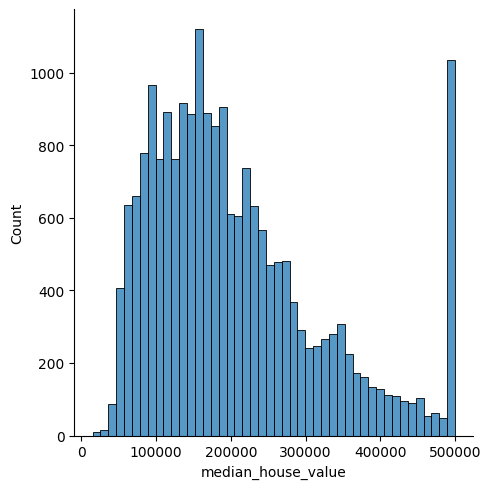

In [57]:
sns.displot(data = housing_df, x = 'median_house_value')

<Axes: xlabel='median_house_value', ylabel='Density'>

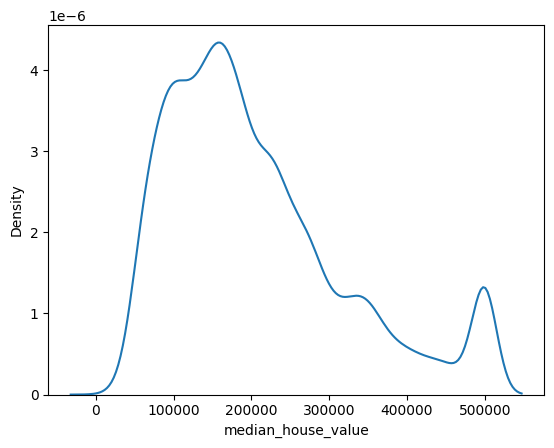

In [58]:
sns.kdeplot(data = housing_df, x = 'median_house_value')

#### 3. Box-plot

<Axes: xlabel='median_house_value'>

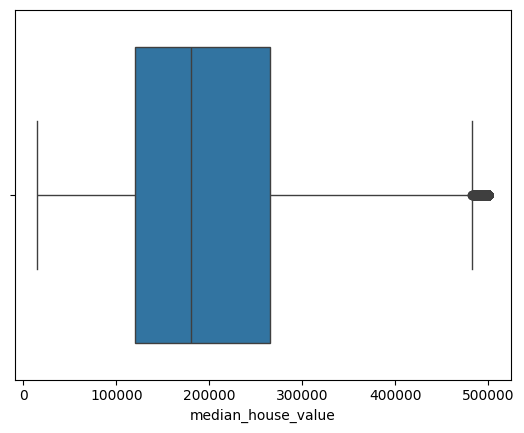

In [59]:
sns.boxplot(data = housing_df, x = 'median_house_value')

<Axes: xlabel='median_income'>

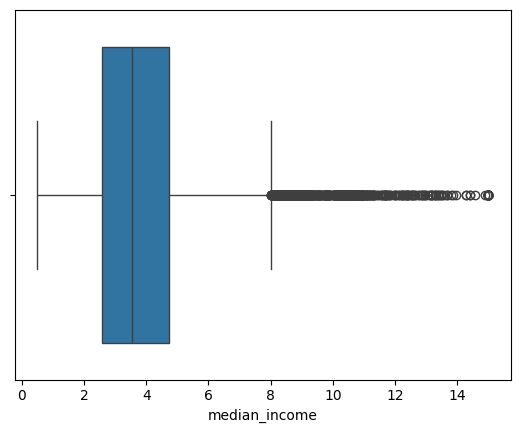

In [60]:
sns.boxplot(data = housing_df, x = 'median_income')

In [61]:
housing_df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

### Bivariate Analysis
* 'Bi' means Two and 'variate' a thing that can vary.
* So when we do an analysis of two variables, its a bivariate analysis.
* Here we try to find a correlation between two variables

#### 1. Numerical-Numerical: Scatterplot

<Axes: xlabel='median_income', ylabel='median_house_value'>

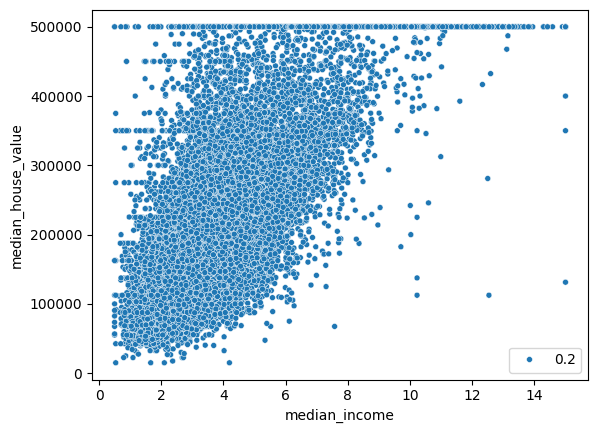

In [62]:
sns.scatterplot(data = housing_df, x = 'median_income', y = 'median_house_value', size = 0.2)

<Axes: xlabel='total_rooms', ylabel='median_house_value'>

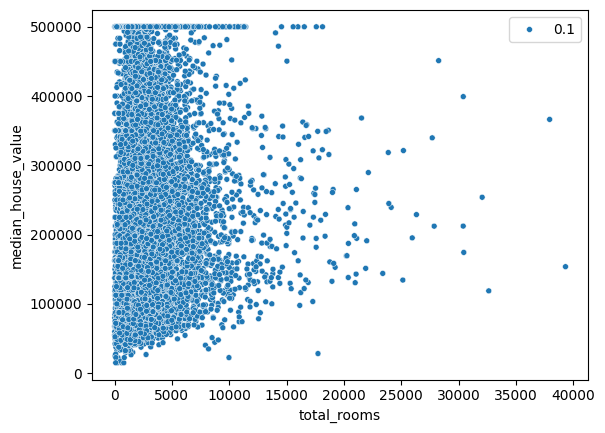

In [63]:
sns.scatterplot(data = housing_df, x = 'total_rooms', y = 'median_house_value', size = 0.1)

#### 2. Numerical - Categorical Variable: Barplot

<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

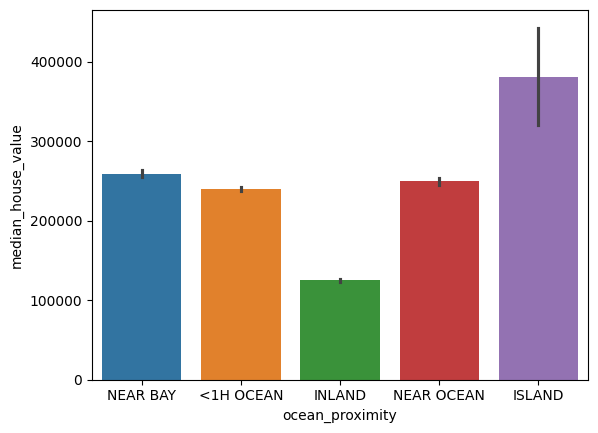

In [69]:
sns.barplot(data = housing_df, x = 'ocean_proximity', y = 'median_house_value', hue = 'ocean_proximity')

#### 3. Numerical-Categorical: Box-Plot

<Axes: ylabel='median_house_value'>

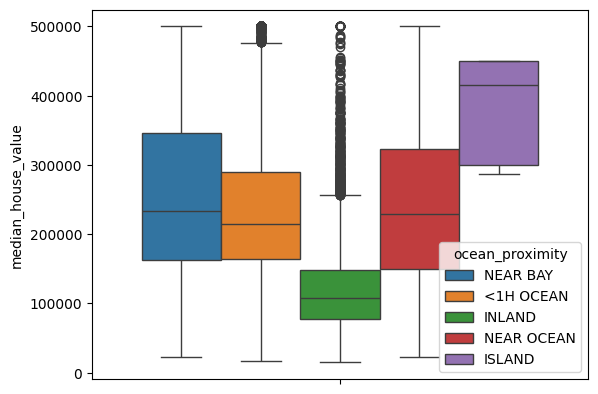

In [70]:
sns.boxplot(data = housing_df, y = 'median_house_value', hue = 'ocean_proximity')

#### 4. Numerical - Categorical Variable: Distplot

<Axes: xlabel='median_house_value', ylabel='Density'>

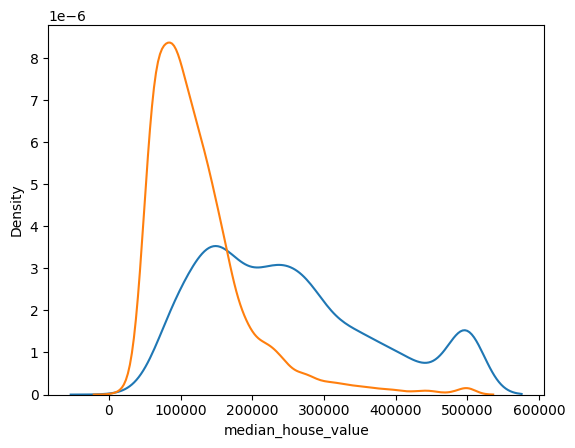

In [77]:
mask1 = housing_df['ocean_proximity'] == 'NEAR OCEAN'
df1 = housing_df.loc[mask1, ['median_house_value']]
mask2 = housing_df['ocean_proximity'] == 'INLAND'
df2 = housing_df.loc[mask2, ['median_house_value']]
sns.kdeplot(data = df1, x = 'median_house_value')
sns.kdeplot(data = df2, x = 'median_house_value')

#### 5. Heat Map (Categorical-Categorical):

In [80]:
tips = sns.load_dataset(name = 'tips')
tips.sample()

,total_bill,tip,sex,smoker,day,time,size
141,34.3,6.7,Male,No,Thur,Lunch,6


<Axes: xlabel='sex', ylabel='day'>

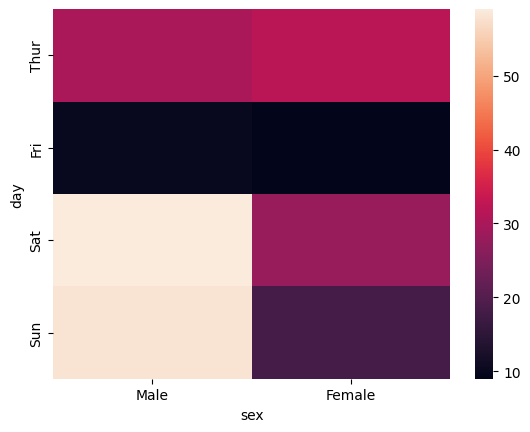

In [ ]:
sns.heatmap(pd.crosstab(tips['day'], tips['sex']))

<Axes: xlabel='sex', ylabel='smoker'>

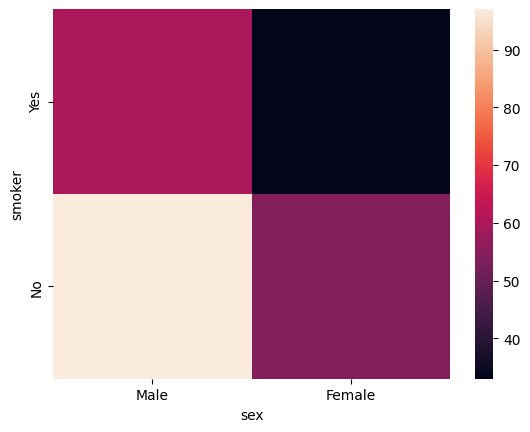

In [ ]:
sns.heatmap(pd.crosstab(tips['smoker'], tips['sex']))

#### 6. Probability:

In [125]:
tips.groupby(by = 'day')['smoker'].value_counts(sort = False)

day   smoker
Thur  No        45
      Yes       17
Fri   No         4
      Yes       15
Sat   No        45
      Yes       42
Sun   No        57
      Yes       19
Name: count, dtype: int64

7. Categorical-Categotical: Cluster Map<br>
* It represents the closeness between categories.
* They are merged till they form a single cluseter per variable
* The lines are called the dendogram.

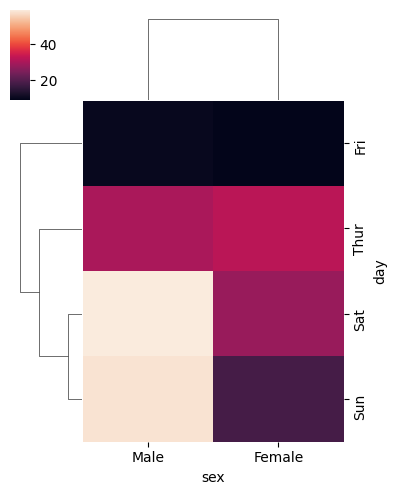

In [129]:
sns.clustermap(data = pd.crosstab(tips['day'], tips['sex']), figsize = (4, 5))

### Multi-Variate-Analysis:

#### Numerical-Numerical-Numerical-.... : Pair plot

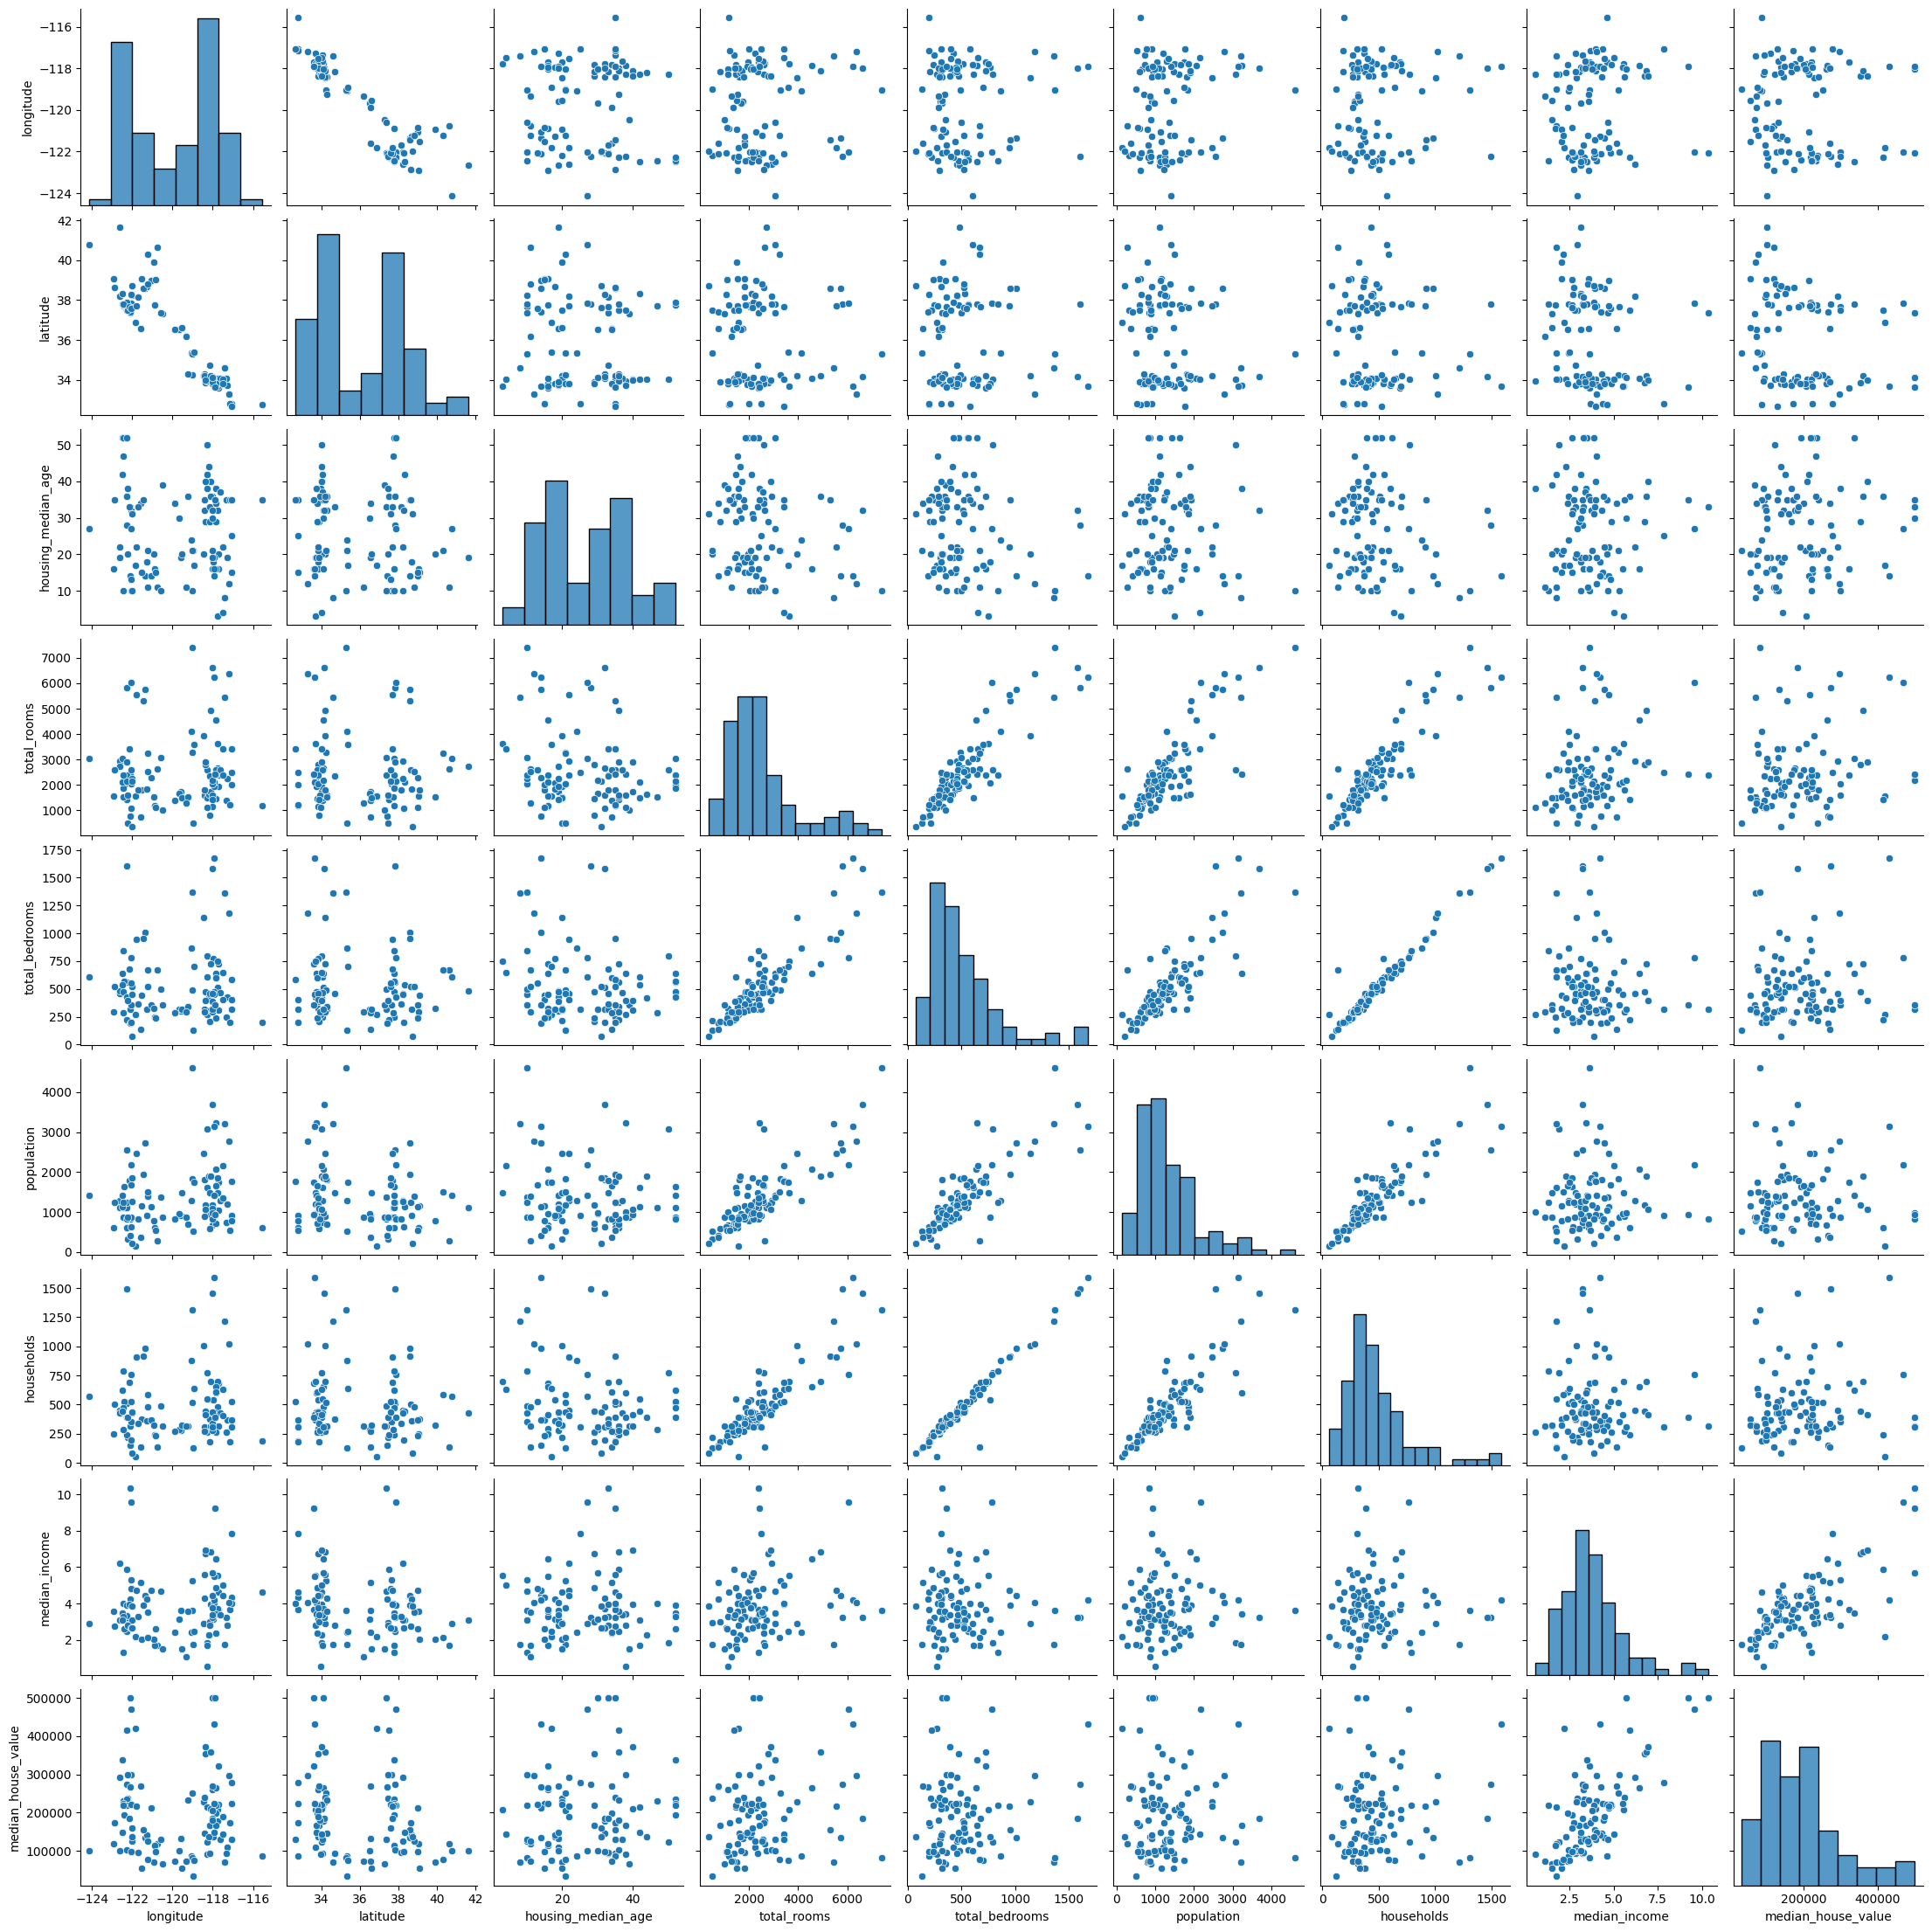

In [136]:
df= housing_df.sample(n = 100)
sns.pairplot(data = df)

Numerical - Numerical - Categorical

<Axes: xlabel='total_rooms', ylabel='median_house_value'>

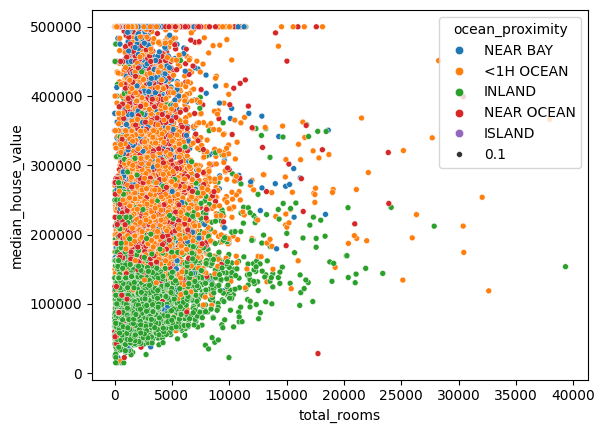

In [65]:
sns.scatterplot(data = housing_df, x = 'total_rooms', y = 'median_house_value', size = 0.1, hue = 'ocean_proximity')

<Axes: xlabel='total_rooms', ylabel='median_house_value'>

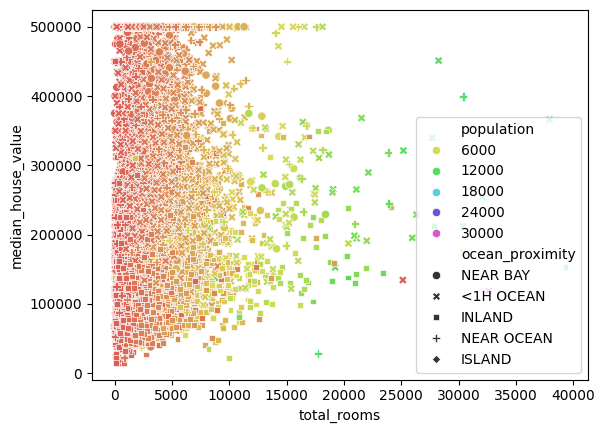

In [66]:
sns.scatterplot(data = housing_df, x = 'total_rooms', y = 'median_house_value', style = 'ocean_proximity', hue = 'population', palette = 'hls')

In [67]:
px.scatter_3d(data_frame = housing_df, x = 'median_income', y = 'median_house_value', z = 'housing_median_age', size = 'total_rooms', color = 'ocean_proximity')